# Project 04: Volatility Forecast Validation & Challenger Analysis

## Notebook 02: GARCH Challenger Development & Diagnostics

## Objective

This notebook develops a Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model as a challenger to the rolling-volatility and EWMA baseline models established in **Project 04, Notebook 01**.

The objective is to assess whether a GARCH(1,1) model provides a statistically defensible representation of time-varying market volatility and produces forecasts suitable for independent out-of-sample evaluation.

The analysis covers:

- GARCH(1,1) model specification and assumptions.
- Parameter estimation using the development sample.
- One-day-ahead out-of-sample volatility forecasting.
- Comparison with rolling-volatility and EWMA forecasts.
- Standardized residual diagnostics and tests for remaining ARCH effects.
- Assessment of parameter plausibility, model convergence and limitations.

## Methodology

The GARCH(1,1) model represents conditional variance as a function of the previous period's squared return innovation and conditional variance.

The model will be estimated using SPY daily returns from the development period established in **Notebook 01**. The estimated parameters will then be used to generate one-day-ahead forecasts over the out-of-sample test period without refitting the model on test observations.

Forecasts will be aligned with the existing rolling-volatility and EWMA forecasts to ensure a consistent comparison.

Formal forecast accuracy evaluation and the final challenger assessment will be conducted in **Project 04, Notebook 03: Out-of-Sample Validation & Challenger Analysis**.

## Research Questions

1. Does GARCH(1,1) produce plausible parameter estimates and converge successfully?
2. Do standardized residuals indicate that important volatility dynamics remain unexplained?
3. How does the GARCH forecast respond to market movements compared with rolling volatility and EWMA?
4. Does GARCH provide a useful challenger for the subsequent out-of-sample validation exercise?

## Project Scope

This notebook focuses on GARCH model development and diagnostics. It uses the same Project 01 data utility and forecasting settings as Notebook 01. The rolling and EWMA baselines are recalculated here using the same formulas so that their forecasts can be aligned with GARCH on a common set of dates.

The primary outputs are GARCH volatility forecasts and diagnostic findings for the out-of-sample evaluation in Notebook 03.

## Data and Configuration

We use the existing Project 01 market-data utility and retain returns as a DataFrame, consistent with Notebook 01. Although this notebook currently uses only SPY, keeping a DataFrame preserves the structure used elsewhere in the project.

In [20]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from project_01_market_risk_engine.src.data import download_prices
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

### Configuration

The settings match Notebook 01 so that both notebooks use the same asset, sample period, rolling window, EWMA decay factor and chronological split.

In [21]:
TICKERS = ["SPY"]

START_DATE = "2015-01-01"
END_DATE = "2026-01-01"

INITIAL_WINDOW = 500
ROLLING_WINDOW = 60
EWMA_LAMBDA = 0.94
TEST_SIZE = 0.30

In [22]:
prices = download_prices(
    tickers=TICKERS,
    start=START_DATE,
    end=END_DATE,
)

prices = prices[["SPY"]].dropna()
returns = prices.pct_change().dropna()

returns.head()

[*********************100%***********************]  1 of 1 completed


Ticker,SPY
Date,
2015-01-05,-0.018060
2015-01-06,-0.009419
2015-01-07,0.012461
2015-01-08,0.017745
2015-01-09,-0.008014


### Data Quality Checks

Confirm the return sample's date range, observation count, missing values and duplicate dates before splitting the data.

In [23]:
print(f"First observation: {returns.index.min().date()}")
print(f"Last observation:  {returns.index.max().date()}")
print(f"Number of returns: {len(returns)}")
print(f"Missing values:\n{returns.isna().sum()}")
print(f"Duplicate dates:   {returns.index.duplicated().sum()}")

First observation: 2015-01-05
Last observation:  2025-12-31
Number of returns: 2765
Missing values:
Ticker
SPY    0
dtype: int64
Duplicate dates:   0


## Development and Test Split

The split is chronological: the first 70% of observations form the development sample used to estimate GARCH parameters, and the final 30% are reserved for out-of-sample forecasts. Test-period returns are used only as they become observable, to update the forecast for the following trading day.

In [24]:
# Earlier observations form the development sample; the latest 30% form the test period.
split_idx = int(len(returns) * (1 - TEST_SIZE))

development_returns = returns.iloc[:split_idx].copy()
test_returns = returns.iloc[split_idx:].copy()

print(f"Development observations: {len(development_returns)}")
print(f"Test observations:        {len(test_returns)}")
print(f"Development period: {development_returns.index.min().date()} "
      f"to {development_returns.index.max().date()}")
print(f"Test period:        {test_returns.index.min().date()} "
      f"to {test_returns.index.max().date()}")

Development observations: 1935
Test observations:        830
Development period: 2015-01-05 to 2022-09-09
Test period:        2022-09-12 to 2025-12-31


## 1. GARCH(1,1) Model Specification and Estimation

### Model Specification

The Generalized Autoregressive Conditional Heteroskedasticity (GARCH) model captures time-varying volatility by allowing conditional variance to depend on previous return shocks and previous conditional variance.

For this project, we use a GARCH(1,1) model:

$$
\begin{aligned}
r_t &= \mu + \epsilon_t \\
\epsilon_t &= \sigma_t z_t \\
\sigma_t^2 &= \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2
\end{aligned}
$$

where:
* $r_t$: daily return at time $t$.
* $\mu$: constant conditional mean.
* $\epsilon_t$: return innovation.
* $\sigma_t^2$: conditional variance.
* $z_t$: standardized innovation, assumed to follow a standard normal distribution in the baseline specification.
* $\omega$: variance intercept.
* $\alpha$: sensitivity of volatility to recent return shocks.
* $\beta$: persistence of previous conditional variance.

### Model Assumptions

The baseline specification uses the following assumptions:

1. The conditional mean is constant.
2. Conditional variance changes over time according to the GARCH(1,1) process.
3. Innovations are conditionally normally distributed.
4. The variance parameters satisfy non-negativity constraints, with a positive variance intercept.
5. For a covariance-stationary variance process, the persistence condition is $\alpha + \beta < 1$.

The sum $\alpha + \beta$ provides an indication of volatility persistence. Values close to one imply that volatility shocks decay slowly.

### Validation Considerations

These assumptions are modeling choices, not guaranteed properties of financial returns. We will examine parameter estimates, convergence, standardized residuals and remaining ARCH effects to identify potential weaknesses.

The normal innovation assumption may not adequately capture the heavy tails commonly observed in financial returns. We will treat this as a limitation of the baseline challenger rather than automatically introduce additional model complexity.

### Estimation Approach

The model is estimated by maximum likelihood on development-period SPY returns only. Returns are scaled to percentage units for estimation; variance forecasts are converted back to decimal-return units before comparison with the baselines.

In [25]:
# Fit GARCH(1,1) using development-period returns only.
garch_returns = development_returns["SPY"].copy()
garch_returns_pct = garch_returns * 100

garch_model = arch_model(
    garch_returns_pct,
    mean="Constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",
    rescale=False,
)

garch_fit = garch_model.fit(disp="off")
print(garch_fit.summary())

                     Constant Mean - GARCH Model Results                      
Dep. Variable:                    SPY   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -2453.36
Distribution:                  Normal   AIC:                           4914.72
Method:            Maximum Likelihood   BIC:                           4936.99
                                        No. Observations:                 1935
Date:                Sat, Oct 10 2026   Df Residuals:                     1934
Time:                        12:05:44   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0912  1.622e-02      5.626  1.843e-08 [5.945e-0

### Parameter Estimates and Interpretation

| Parameter | Estimate | Interpretation |
| :--- | ---: | :--- |
| $\mu$ | 0.0912 | Estimated constant mean return, in percentage-return units |
| $\omega$ | 0.0418 | Variance intercept, in percentage-return-squared units |
| $\alpha_1$ | 0.2266 | Weight on the previous period's squared innovation |
| $\beta_1$ | 0.7473 | Weight on the previous period's conditional variance |

The estimated ARCH and GARCH coefficients are both positive. Volatility persistence is:

$$
\alpha_1 + \beta_1 = 0.2266 + 0.7473 = 0.9739
$$

The sum is below one and close to it, consistent with highly persistent conditional variance under this specification. The fitted summary reports statistically significant estimates for the constant mean and the three variance parameters. Parameter plausibility and optimizer convergence are checked separately below.

These in-sample estimates and diagnostics do not establish that GARCH forecasts better than the rolling or EWMA baselines; that question is reserved for Notebook 03.

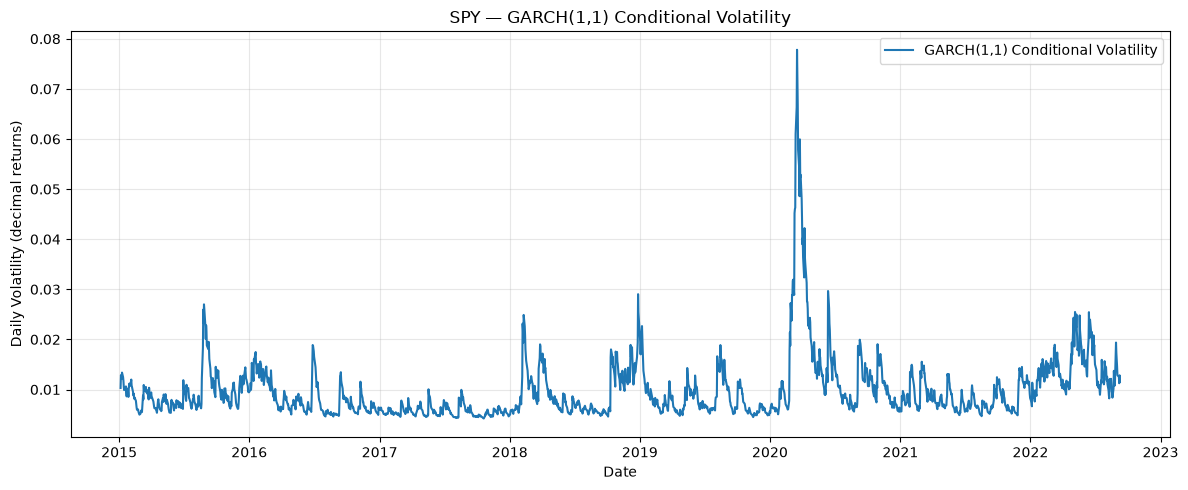

In [26]:
# Convert fitted conditional volatility from percentage to decimal units.
garch_volatility = garch_fit.conditional_volatility / 100

plt.figure(figsize=(12, 5))
plt.plot(
    garch_volatility.index,
    garch_volatility,
    label="GARCH(1,1) Conditional Volatility",
)
plt.title("SPY — GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Daily Volatility (decimal returns)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Generate One-Day-Ahead GARCH Forecasts

We use the parameters estimated on the development sample to forecast conditional variance over the test period. Parameters remain fixed throughout the test period, but the conditional variance forecast is updated as each new return becomes observable.

For each test date \(t\), the forecast uses information available through \(t-1\). This avoids look-ahead bias and creates a fair basis for comparison with the rolling-volatility and EWMA forecasts.

In [27]:
mu = garch_fit.params["mu"]
omega = garch_fit.params["omega"]
alpha = garch_fit.params["alpha[1]"]
beta = garch_fit.params["beta[1]"]

all_returns_pct = returns["SPY"] * 100
last_development_date = development_returns.index[-1]
last_return_pct = all_returns_pct.loc[last_development_date]
last_variance_pct = garch_fit.conditional_volatility.iloc[-1] ** 2

# Use the final development observation to form the first test-day forecast.
last_shock = last_return_pct - mu
conditional_variance = (
    omega
    + alpha * last_shock**2
    + beta * last_variance_pct
)

garch_variance_forecasts_pct = []

for date in test_returns.index:
    # Save the forecast before observing the return on this date.
    garch_variance_forecasts_pct.append(conditional_variance)

    current_shock = all_returns_pct.loc[date] - mu
    conditional_variance = (
        omega
        + alpha * current_shock**2
        + beta * conditional_variance
    )

# Convert variance from percentage-return-squared to decimal-return-squared.
garch_variance_test = pd.DataFrame(
    {
        "GARCH_Variance": np.array(garch_variance_forecasts_pct) / 100**2
    },
    index=test_returns.index,
)

print(f"Forecasts generated: {len(garch_variance_test)}")
print(f"Missing forecasts: {garch_variance_test.isna().sum().sum()}")

garch_variance_test.head()

Forecasts generated: 830
Missing forecasts: 0


,GARCH_Variance
Date,
2022-09-12,0.000153
2022-09-13,0.000141
2022-09-14,0.000556
2022-09-15,0.000421
2022-09-16,0.000353


## 3. Forecast Alignment, Quality Checks and Comparison

The rolling and EWMA forecasts are recomputed using the same formulas and settings as Notebook 01. Forecasts are then aligned with GARCH and actual returns on the test dates. All variance forecasts remain in decimal-return-squared units.

In [28]:
# Recompute the baseline forecasts with one-day-ahead timing.
rolling_variance = (
    returns.shift(1)
    .rolling(window=ROLLING_WINDOW)
    .var(ddof=1)
)

ewma_variance = (
    returns.pow(2)
    .ewm(
        alpha=1 - EWMA_LAMBDA,
        adjust=False,
        min_periods=INITIAL_WINDOW,
    )
    .mean()
    .shift(1)
)

forecast_comparison = pd.concat(
    [
        test_returns["SPY"].rename("Actual_Return"),
        rolling_variance.loc[test_returns.index, "SPY"].rename("Rolling_Variance"),
        ewma_variance.loc[test_returns.index, "SPY"].rename("EWMA_Variance"),
        garch_variance_test["GARCH_Variance"],
    ],
    axis=1,
)

variance_columns = ["Rolling_Variance", "EWMA_Variance", "GARCH_Variance"]

print("Test observations:", len(forecast_comparison))
print("\nMissing values:")
print(forecast_comparison.isna().sum())
print("\nNon-positive variance forecasts:")
print((forecast_comparison[variance_columns] <= 0).sum())
print("\nDuplicate dates:", forecast_comparison.index.duplicated().sum())

forecast_comparison.head()

Test observations: 830

Missing values:
Actual_Return       0
Rolling_Variance    0
EWMA_Variance       0
GARCH_Variance      0
dtype: int64

Non-positive variance forecasts:
Rolling_Variance    0
EWMA_Variance       0
GARCH_Variance      0
dtype: int64

Duplicate dates: 0


,Actual_Return,Rolling_Variance,EWMA_Variance,GARCH_Variance
Date,,,,
2022-09-12,0.010748,0.000180,0.000167,0.000153
2022-09-13,-0.043483,0.000179,0.000164,0.000141
2022-09-14,0.003816,0.000193,0.000268,0.000556
2022-09-15,-0.011353,0.000193,0.000252,0.000421
2022-09-16,-0.007629,0.000186,0.000245,0.000353


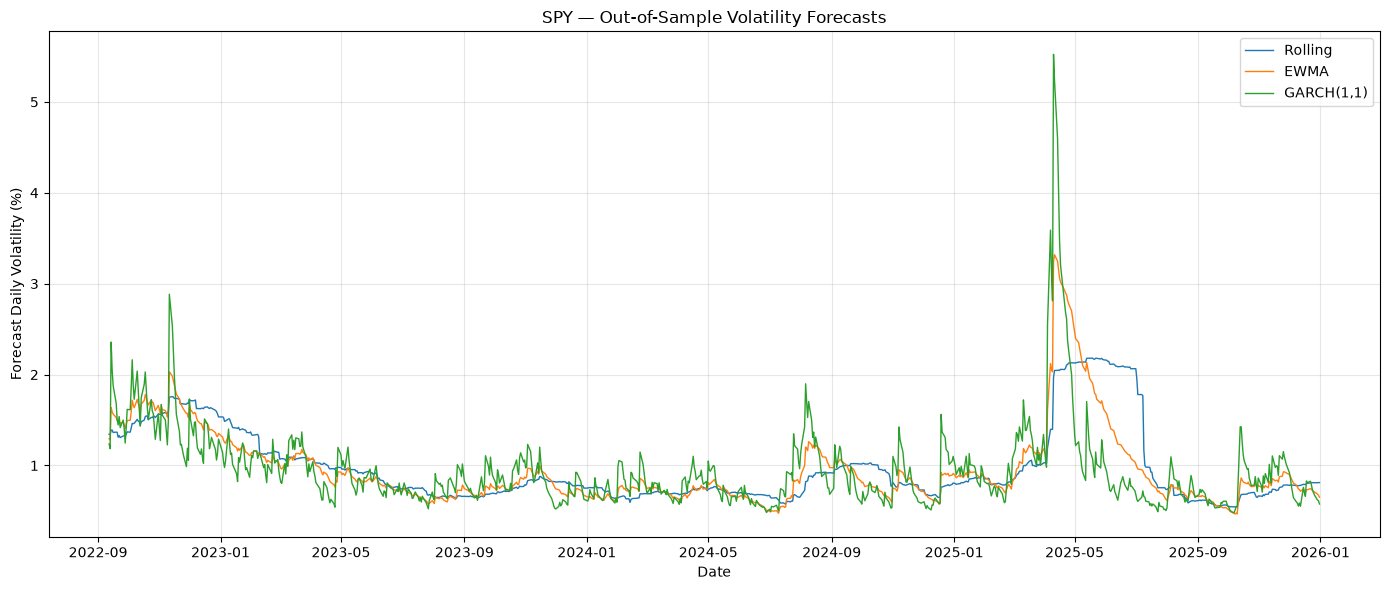

In [29]:
# Plot daily volatility, converting decimal volatility to percentage units.
volatility_comparison = pd.DataFrame(
    {
        "Rolling": np.sqrt(forecast_comparison["Rolling_Variance"]),
        "EWMA": np.sqrt(forecast_comparison["EWMA_Variance"]),
        "GARCH(1,1)": np.sqrt(forecast_comparison["GARCH_Variance"]),
    },
    index=forecast_comparison.index,
)

plt.figure(figsize=(14, 6))

for column in volatility_comparison.columns:
    plt.plot(
        volatility_comparison.index,
        volatility_comparison[column] * 100,
        label=column,
        linewidth=1,
    )

plt.title("SPY — Out-of-Sample Volatility Forecasts")
plt.xlabel("Date")
plt.ylabel("Forecast Daily Volatility (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Forecast Comparison — Initial Observations

- All three models provide forecasts for the same 830 test dates, with no missing or non-positive variance forecasts.
- Rolling volatility is comparatively smooth because it uses a fixed-length window.
- EWMA responds to recent shocks while smoothing their impact through exponentially declining weights.
- GARCH(1,1) shows sharper short-term changes in this sample, reflecting its recursive response to shocks and prior conditional variance.
- A focused comparison of the April 2025 episode follows. These plots describe forecast behavior; they do not establish comparative forecast accuracy, which is evaluated in Notebook 03.

## 4. Forecast Behavior During the April 2025 Episode

In [30]:
# Inspect the period around the maximum GARCH volatility forecast.
peak_date = volatility_comparison["GARCH(1,1)"].idxmax()

window_start = peak_date - pd.Timedelta(days=7)
window_end = peak_date + pd.Timedelta(days=7)
episode = forecast_comparison.loc[window_start:window_end].copy()

episode["Actual_Return_Pct"] = episode["Actual_Return"] * 100
episode["Rolling_Volatility_Pct"] = np.sqrt(episode["Rolling_Variance"]) * 100
episode["EWMA_Volatility_Pct"] = np.sqrt(episode["EWMA_Variance"]) * 100
episode["GARCH_Volatility_Pct"] = np.sqrt(episode["GARCH_Variance"]) * 100

episode[
    [
        "Actual_Return_Pct",
        "Rolling_Volatility_Pct",
        "EWMA_Volatility_Pct",
        "GARCH_Volatility_Pct",
    ]
].round(3)

,Actual_Return_Pct,Rolling_Volatility_Pct,EWMA_Volatility_Pct,GARCH_Volatility_Pct
Date,,,,
2025-04-03,-4.928,1.021,1.101,0.981
2025-04-04,-5.854,1.195,1.612,2.544
2025-04-07,-0.178,1.398,2.121,3.590
2025-04-08,-1.566,1.397,2.057,3.113
2025-04-09,10.502,1.398,2.031,2.811
2025-04-10,-4.382,1.969,3.239,5.523
2025-04-11,1.784,2.046,3.319,5.232
2025-04-14,0.970,2.045,3.247,4.599
2025-04-15,-0.280,2.051,3.157,4.002


The test period includes several large SPY returns in early April 2025, including a decline of approximately 5.85% on April 4 and a gain of approximately 10.50% on April 9. In the forecast table, GARCH volatility reaches approximately 5.52% on April 10, while EWMA reaches 3.24% and rolling volatility 1.97%.

The timing is consistent with one-day-ahead forecasting: the April 9 return affects the April 10 forecast, not the forecast for April 9. GARCH and EWMA then decline over the following days, while rolling volatility remains comparatively flat and even rises slightly as its fixed window incorporates the episode. This illustrates differences in responsiveness, not forecast superiority.

## 5. Standardized Residual Diagnostics

Standardized residuals are obtained by dividing the fitted residuals by their estimated conditional volatility. If the GARCH model captures the conditional variance dynamics adequately, the standardized residuals should exhibit reduced autocorrelation and limited remaining ARCH effects.

We examine residual autocorrelation, squared-residual autocorrelation, and remaining ARCH effects. These tests help assess model adequacy, although they do not establish out-of-sample forecast accuracy.

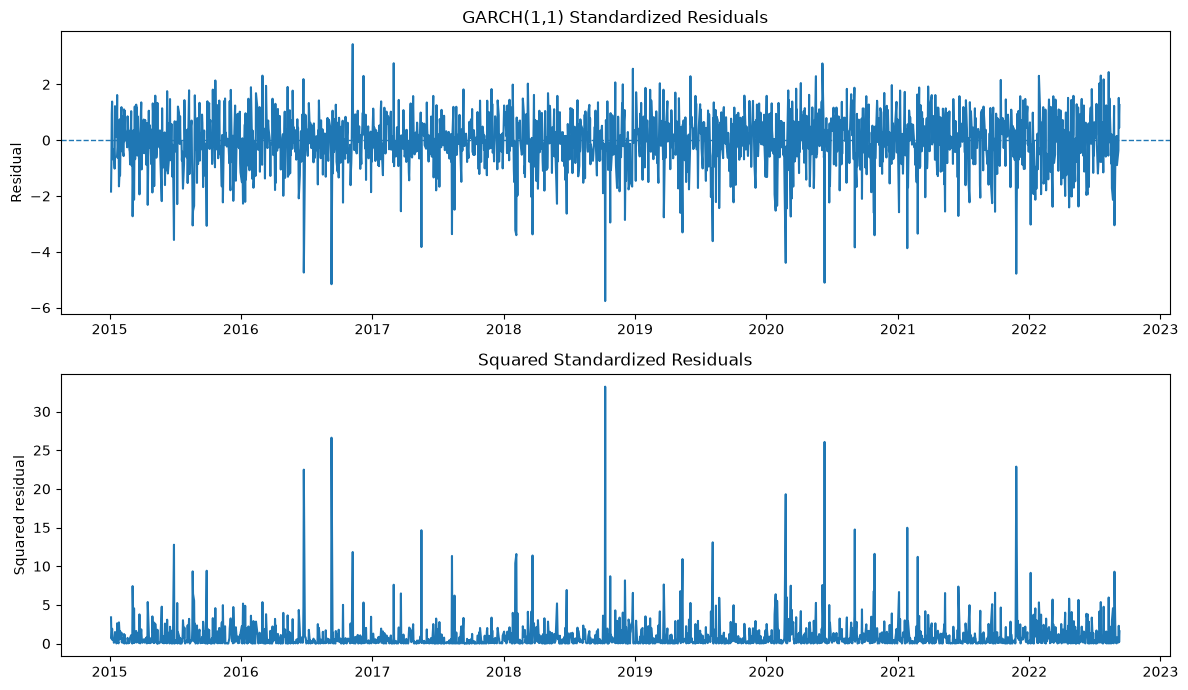

Ljung–Box test: standardized residuals


,lb_stat,lb_pvalue
10,7.131910,0.712936
20,16.445829,0.688609


Ljung–Box test: squared standardized residuals


,lb_stat,lb_pvalue
10,10.157211,0.426811
20,14.797016,0.787902


ARCH LM statistic: 9.9799
ARCH LM p-value: 0.442256


c:\Users\hp\Documents\Risk Portfolio\quantitative-risk-model-validation\.venv\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(


In [31]:
# Standardized residuals from the fitted development-period model.
standardized_residuals = pd.Series(
    garch_fit.std_resid,
    index=garch_returns_pct.index,
).dropna()

# Plot standardized residuals and their squares.
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].plot(standardized_residuals.index, standardized_residuals)
axes[0].axhline(0, linestyle="--", linewidth=1)
axes[0].set_title("GARCH(1,1) Standardized Residuals")
axes[0].set_ylabel("Residual")

axes[1].plot(
    standardized_residuals.index,
    standardized_residuals**2,
)
axes[1].set_title("Squared Standardized Residuals")
axes[1].set_ylabel("Squared residual")

plt.tight_layout()
plt.show()

# Ljung–Box tests for autocorrelation in residuals and squared residuals.
print("Ljung–Box test: standardized residuals")
display(
    acorr_ljungbox(
        standardized_residuals,
        lags=[10, 20],
        return_df=True,
    )
)

print("Ljung–Box test: squared standardized residuals")
display(
    acorr_ljungbox(
        standardized_residuals**2,
        lags=[10, 20],
        return_df=True,
    )
)

# Engle ARCH test for remaining conditional heteroskedasticity.
arch_test_stat, arch_test_pvalue, _, _ = het_arch(
    standardized_residuals,
    nlags=10,
)

print(f"ARCH LM statistic: {arch_test_stat:.4f}")
print(f"ARCH LM p-value: {arch_test_pvalue:.6f}")

### Residual Diagnostic Findings

- The Ljung–Box tests do not detect significant autocorrelation in standardized residuals at lags 10 or 20 (p-values 0.713 and 0.689).
- The Ljung–Box tests do not detect significant autocorrelation in squared standardized residuals at lags 10 or 20 (p-values 0.427 and 0.788).
- The ARCH LM test does not detect significant remaining ARCH effects at the 5% significance level (p-value 0.442).
- These findings are consistent with the fitted model capturing important conditional variance dynamics in the development sample. They do not prove correct specification or out-of-sample predictive superiority.

## 6. Model Convergence and Parameter Validity

Check that optimization completed successfully and that the estimated variance parameters satisfy the standard non-negativity and persistence conditions.

In [32]:
# Check optimizer convergence and GARCH parameter constraints.
persistence = alpha + beta

print("Convergence flag:", garch_fit.convergence_flag)
print("Optimizer details:", garch_fit.optimization_result.message)

print(f"\nOmega: {omega:.6f}")
print(f"Alpha: {alpha:.6f}")
print(f"Beta:  {beta:.6f}")
print(f"Alpha + Beta: {persistence:.6f}")

print("\nParameter checks:")
print("Omega > 0:", omega > 0)
print("Alpha >= 0:", alpha >= 0)
print("Beta >= 0:", beta >= 0)
print("Persistence < 1:", persistence < 1)

Convergence flag: 0
Optimizer details: Optimization terminated successfully

Omega: 0.041806
Alpha: 0.226600
Beta:  0.747272
Alpha + Beta: 0.973872

Parameter checks:
Omega > 0: True
Alpha >= 0: True
Beta >= 0: True
Persistence < 1: True


## 7. Key Findings and Conclusion

### Model Estimation
- The GARCH(1,1) model was estimated on 1,935 development-period SPY returns and the optimizer converged successfully.
- The estimated ARCH and GARCH coefficients are 0.2266 and 0.7473, respectively.
- Persistence is high ($\alpha+\beta=0.9739$), but remains below one.

### Model Diagnostics
- The residual autocorrelation tests and ARCH LM test do not detect significant remaining effects at the tested lags.
- These results support using the fitted model as a challenger, while leaving open other limitations such as the normal-innovation assumption and extreme observations.

### Forecast Behavior
- Rolling volatility is comparatively smooth, EWMA responds to recent observations, and GARCH shows sharper short-term changes during the April 2025 episode.
- All three models are aligned over the same 830 test dates. The comparison of forecast behavior is descriptive, not a ranking of predictive accuracy.

### Next Step
Notebook 03 will compare the models using out-of-sample loss functions, including mean squared error on squared returns and QLIKE. The forecasts and realized proxy must use consistent units and one-day-ahead timing.

**Conclusion:** The GARCH(1,1) model is a viable challenger for formal out-of-sample evaluation. Its predictive value relative to rolling volatility and EWMA remains to be established.